Bayesian Demand Forecasting

In [ ]:
#Things that have been taking out from my code
#from pymc import plot_posterior_predictive_glm # also turned out that plot_posterior_predictive was used in pymc3 but has been discontinued in pymc.
#Switching out my process

#import warnings
#warnings.filterwarnings("ignore")

        # Priors
        # alpha - what is the average starting demand if the time = 0
        # beta - rate of change of demand over time
        # prior - what is believed about the data before seeing it
        # posterior - teh prior is updated after the data is seen

        #Initially I used a linear plot, demand and time but I switched up to inclide other factors to make the factor more robust

        #i had to get data that had more features switch from a linear bayesian olot to a multivalue bayesian plot add fourier seasonality

        #I split my data into train and test, 2014-2022 amd 2023-2024, first training is done with 2014-2022, test is 20



Global Imports


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import os

Dataset Simulation

In [ ]:
np.random.seed(42)

# Farms
farms = ['Farm_1', 'Farm_2', 'Farm_3', 'Farm_4', 'Farm_5']

# Date range
date_range = pd.date_range(start="2014-01-01", end="2024-12-01", freq="MS")  # Monthly start

data = []

for farm in farms:
    base_demand = np.random.uniform(2500, 4000)  # baseline farm demand
    for date in date_range:
        # Simulate temperature seasonally (°C)
        month = date.month
        temp = 25 + 5 * np.sin(2 * np.pi * (month - 1) / 12) + np.random.normal(0, 1.5)

        # Simulate rainfall (mm) - rainy season assumed April–Oct
        rainfall = np.random.normal(80 if 4 <= month <= 10 else 20, 10)

        # Simulate demand: higher in dry season due to scarcity
        demand = base_demand + \
                 200 * np.cos(2 * np.pi * (month - 1) / 12) + \
                 np.random.normal(0, 200)

        # Simulate price with seasonality and randomness (₦ per kg)
        price = 180 + 20 * np.cos(2 * np.pi * (month - 1) / 12) + np.random.normal(0, 10)

        # Household income (₦/month) – grows slowly over time
        years_since_2014 = (date.year - 2014) + (date.month - 1) / 12
        income = 45000 + years_since_2014 * 1000 + np.random.normal(0, 3000)

        data.append({
            "Farm_ID": farm,
            "Date": date,
            "Demand_kg": max(0, demand),
            "AvgTemp_C": round(temp, 2),
            "Rainfall_mm": round(max(rainfall, 0), 2),
            "Price_per_kg": round(max(price, 0), 2),
            "Household_Income": round(max(income, 0), 2)
        })

# Create DataFrame
df_simulated = pd.DataFrame(data)

df_simulated.to_csv("Simulated_Smallholder_Historical_2014_2024.csv", index=False)


Splitting Data into Train and Test


In [ ]:
# Load your simulated dataset
df = pd.read_csv("Simulated_Smallholder_Historical_2014_2024.csv")

# Ensure Date column is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Split into training and testing sets
train_df = df[df['Date'] < '2023-01-01']
test_df = df[df['Date'] >= '2023-01-01']

# Optional: verify split
print("Training data range:", train_df['Date'].min(), "to", train_df['Date'].max())
print("Testing data range:", test_df['Date'].min(), "to", test_df['Date'].max())


train_df.to_csv("Train_2014_2022.csv", index=False)
test_df.to_csv("Test_2023_2024.csv", index=False)


Training data range: 2014-01-01 00:00:00 to 2022-12-01 00:00:00
Testing data range: 2023-01-01 00:00:00 to 2024-12-01 00:00:00


In [ ]:
np.random.seed(42)

# Number of farms
n_farms = 10

# Simulate farm data
farm_ids = [f"F{i+1}" for i in range(n_farms)]
farm_sizes = np.random.uniform(0.5, 2.0, size=n_farms).round(2)  # About 90% of tomatoes are grown by small farmers ... they cultivate between 0.5 and 4 ha of land hectares (Akinola et al., 2023)
yield_per_ha = np.random.uniform(4, 8, size=n_farms).round(2)     # tons per hectare
planting_cost = np.random.uniform(80000, 250000, size=n_farms).round(2)  # Naira per hectare
labor_count = np.random.randint(3, 10, size=n_farms)  # total available laborers per farm
planted_labor_per_ha = np.random.uniform(2, 5, size=n_farms).round(2)  # labor required per ha

# Create DataFrame
farm_df = pd.DataFrame({
    "Farm_ID": farm_ids,
    "Farm_Size_ha": farm_sizes,
    "Yield_t_per_ha": yield_per_ha,
    "Planting_Cost_per_ha": planting_cost,
    "Labor_Count": labor_count,
    "Planted_Labor_per_ha": planted_labor_per_ha
})

# Save to CSV
farm_df.to_csv("Simulated_Farm_Info.csv", index=False)

# Preview
print(farm_df)


  Farm_ID  Farm_Size_ha  Yield_t_per_ha  Planting_Cost_per_ha  Labor_Count  \
0      F1          1.06            4.08             184014.99            5   
1      F2          1.93            7.88             103713.96            9   
2      F3          1.60            7.33             129664.59            7   
3      F4          1.40            4.85             142281.51            3   
4      F5          0.73            4.73             157531.90            9   
5      F6          0.73            4.73             213479.91            4   
6      F7          0.59            5.22             113944.54            6   
7      F8          1.80            6.10             167419.85            3   
8      F9          1.40            5.73             180710.48            6   
9     F10          1.56            5.16              87896.57            8   

   Planted_Labor_per_ha  
0                  4.43  
1                  2.91  
2                  2.29  
3                  4.05  
4          

Training Data Aggregation

In [ ]:
# Step 1: Load the training dataset
df = pd.read_csv("Training_Data_2014_2022.csv")

# Step 2: Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Step 3: Aggregate by Date (i.e., across all farms)
df_coop = df.groupby('Date').agg({
    'Demand_kg': 'sum',               # total demand across farms
    'AvgTemp_C': 'mean',              # average temp
    'Rainfall_mm': 'mean',            # average rainfall
    'Price_per_kg': 'mean',           # average market price
    'Household_Income': 'mean'        # average income
}).reset_index()


In [ ]:
#Aggregating my test data before testing
# Step 1: Load the training dataset
df = pd.read_csv("Testing_Data_2023_2024.csv")

# Step 2: Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Step 3: Aggregate by Date (i.e., across all farms)
df_coop_test = df.groupby('Date').agg({
    'Demand_kg': 'sum',               # total demand across farms
    'AvgTemp_C': 'mean',              # average temp
    'Rainfall_mm': 'mean',            # average rainfall
    'Price_per_kg': 'mean',           # average market price
    'Household_Income': 'mean'        # average income
}).reset_index()

Core 1: Bayesian Linear Regression

In [ ]:
# Fourier seasonality setup
fourier_order = 2
period = 12

def make_fourier_series(x, order, period):
    return np.vstack([
        fn(2 * np.pi * (i+1) * x / period)
        for i in range(order)
        for fn in (np.sin, np.cos)
    ]).T

def forecast_hybrid(df_coop, df_coop_test, forecast_horizon=6, update_every=3):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

    step = 0
    all_forecasts = []
    actuals = []
    forecasted_samples_all = []
    lower_bounds = []
    upper_bounds = []

    df_train = df_coop.copy()
    df_test = df_coop_test.copy()

    df_train['Date'] = pd.to_datetime(df_train['Date'])
    df_test['Date'] = pd.to_datetime(df_test['Date'])

    while step < forecast_horizon:
        print(f"\nForecasting from month {step + 1} to {step + update_every}...")

        # Forecast window
        df_test_window = df_test.iloc[step:step + update_every]
        n_steps = len(df_test_window)
        if n_steps == 0:
            break

        # Training data
        df_train.set_index("Date", inplace=True)
        y = df_train['Demand_kg'].values
        n = len(y)
        X = df_train[['AvgTemp_C', 'Rainfall_mm', 'Price_per_kg', 'Household_Income']].values
        x = np.arange(n)
        x_season = make_fourier_series(x, fourier_order, period)

        # Forecast data
        X_future = df_test_window[['AvgTemp_C', 'Rainfall_mm', 'Price_per_kg', 'Household_Income']].values
        x_forecast = np.arange(n, n + n_steps)
        x_forecast_season = make_fourier_series(x_forecast, fourier_order, period)

        # Bayesian model
        with pm.Model() as model:
            alpha = pm.Normal("alpha", mu=0, sigma=10)
            beta = pm.Normal("beta", mu=0, sigma=1, shape=X.shape[1])
            sigma = pm.HalfNormal("sigma", sigma=10)
            season_coeffs = pm.Normal("season_coeffs", mu=0, sigma=5, shape=x_season.shape[1])

            mu = alpha + pm.math.dot(X, beta) + pm.math.dot(x_season, season_coeffs)
            pm.Normal("y", mu=mu, sigma=sigma, observed=y)

            mu_forecast = alpha + pm.math.dot(X_future, beta) + pm.math.dot(x_forecast_season, season_coeffs)
            y_forecast = pm.Normal("y_forecast", mu=mu_forecast, sigma=sigma, shape=n_steps)

            trace = pm.sample(draws=500, tune=500, target_accept=0.9, cores=1, return_inferencedata=True)

        forecast_samples = trace.posterior["y_forecast"].values.reshape(-1, n_steps)
        forecasted_samples_all.append(forecast_samples)

        forecast_means = forecast_samples.mean(axis=0)
        lower = np.percentile(forecast_samples, 2.5, axis=0)
        upper = np.percentile(forecast_samples, 97.5, axis=0)

        for i in range(n_steps):
            forecast_mean = forecast_means[i]
            actual = df_test_window['Demand_kg'].values[i]
            ci_lower = lower[i]
            ci_upper = upper[i]
            print(f"Month {step + i + 1}: Forecast = {forecast_mean:.2f} kg | Actual = {actual:.2f} kg | 95% CI = [{ci_lower:.2f}, {ci_upper:.2f}]")

        lower_bounds.extend(lower)
        upper_bounds.extend(upper)
        all_forecasts.extend(forecast_means)
        actuals.extend(df_test_window['Demand_kg'].values)

        # Update training set
        df_train = df_train.reset_index()
        df_train = pd.concat([df_train, df_test_window], ignore_index=True)
        step += update_every

    # --- After all forecasts ---
    months = np.arange(1, len(actuals) + 1)
    all_forecasts = np.array(all_forecasts)
    actuals = np.array(actuals)
    lower_bounds = np.array(lower_bounds)
    upper_bounds = np.array(upper_bounds)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(months, actuals, 'o-', label='Actual Demand', color='black')
    plt.plot(months, all_forecasts, 'o--', label='Forecasted Mean', color='green')
    plt.fill_between(months, lower_bounds, upper_bounds, color="green", alpha=0.3, label="95% CI")
    plt.xlabel("Forecast Month")
    plt.ylabel("Demand (kg)")
    plt.title("Hybrid Forecast (6-Month Horizon, Retrain Every 3)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return all_forecasts, actuals, forecasted_samples_all



Forecasting from month 1 to 3...


Month 1: Forecast = 1812.10 kg | Actual = 2230.30 kg | 95% CI = [1506.83, 2130.62]
Month 2: Forecast = 1972.92 kg | Actual = 2174.00 kg | 95% CI = [1692.05, 2268.20]
Month 3: Forecast = 2078.62 kg | Actual = 2140.50 kg | 95% CI = [1779.86, 2375.28]

Forecasting from month 4 to 6...


Month 4: Forecast = 1999.27 kg | Actual = 2154.80 kg | 95% CI = [1697.10, 2315.60]
Month 5: Forecast = 2001.87 kg | Actual = 1938.20 kg | 95% CI = [1701.92, 2301.79]
Month 6: Forecast = 1863.33 kg | Actual = 1919.00 kg | 95% CI = [1575.45, 2179.05]


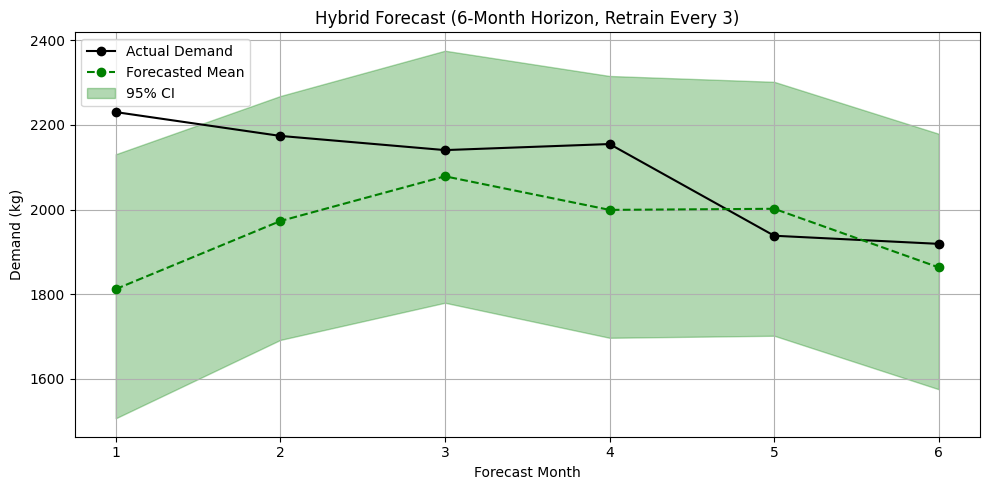

In [ ]:
forecasted, actuals, forecasted_samples_all = forecast_hybrid(df_coop, df_coop_test)


Evaluation Metrics

Point Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(actuals, forecasted)
rmse = mean_squared_error(actuals, forecasted) ** 0.5
mape = mean_absolute_percentage_error(actuals, forecasted) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


MAE: 159.34
RMSE: 204.33
MAPE: 7.38%


Probabilistic Evaluation Metrics

In [ ]:
!pip install properscoring

In [ ]:
forecasted_samples_all = np.array(forecasted_samples_all)  # Should be (2, 1000, 3) in your case
forecasted_samples_all = forecasted_samples_all.reshape(-1, forecasted_samples_all.shape[1])

In [ ]:
from properscoring import crps_ensemble
import numpy as np

# forecasted_samples_all: shape (6, 1000)
# actuals: shape (6,)

crps_scores = [
    crps_ensemble(actuals[i], forecasted_samples_all[i])
    for i in range(len(actuals))
]

mean_crps = np.mean(crps_scores)

print("CRPS Scores:", crps_scores)
print(f"Mean CRPS: {mean_crps:.2f}")


CRPS Scores: [np.float64(184.28205193508342), np.float64(131.6691324241532), np.float64(111.97960782030695), np.float64(124.84281684940672), np.float64(40.609515218358055), np.float64(44.520756739196386)]
Mean CRPS: 106.32


In [ ]:
# Correct axis = 1 because we want bounds for each forecast point across its 1000 samples
lower = np.percentile(forecasted_samples_all, 2.5, axis=1)
upper = np.percentile(forecasted_samples_all, 97.5, axis=1)

# Compute empirical coverage: how many actuals fall inside the 95% prediction interval
coverage = np.mean((actuals >= lower) & (actuals <= upper)) * 100
print(f"95% Prediction Interval Coverage: {coverage:.2f}%")


95% Prediction Interval Coverage: 100.00%


In [ ]:
#Forecast diagnostics
#Statistical convergence diagnostics show that my
#r-hat is about 1.0
# ess_bulk is greater that 1000
# and that there are no divergences

Core 2: Monte Carlo Simulation (Estimate Revenue under Loss constraints)

Month 1: Adjusted Demand (mean) = 1759.37 kg
Month 2: Adjusted Demand (mean) = 1752.85 kg
Month 3: Adjusted Demand (mean) = 1756.23 kg
Month 4: Adjusted Demand (mean) = 1750.13 kg
Month 5: Adjusted Demand (mean) = 1770.77 kg
Month 6: Adjusted Demand (mean) = 1775.70 kg


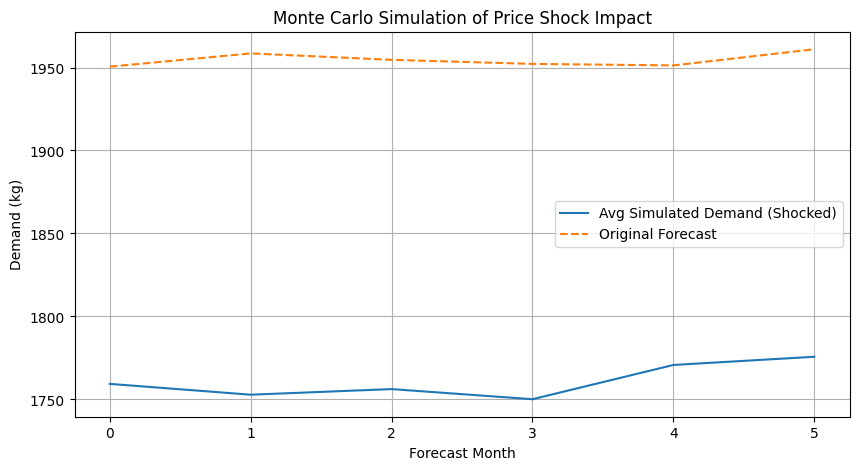

In [ ]:
# Assume you have forecasted_samples_all (shape: [steps, draws])
# Simulate price shock: 20% price increase = demand drops by 10%

def simulate_shock(forecasted_samples_all, price_shock_rate=0.2, demand_elasticity=-0.5, n_sim=1000):
    n_steps, n_draws = forecasted_samples_all.shape
    simulated_demand = np.zeros((n_sim, n_steps))

    for sim in range(n_sim):
        for t in range(n_steps):
            samples = forecasted_samples_all[t]
            # Simulate price shock
            price_shock = np.random.binomial(1, price_shock_rate)
            shock_multiplier = 1 + (demand_elasticity * price_shock)
            adjusted_samples = samples * shock_multiplier
            simulated_demand[sim, t] = np.mean(adjusted_samples)

    return simulated_demand

# Run simulation
simulated_demand = simulate_shock(forecasted_samples_all)
mean_shocked = simulated_demand.mean(axis=0)
for t, value in enumerate(mean_shocked):
    print(f"Month {t+1}: Adjusted Demand (mean) = {value:.2f} kg")


# Plot average simulated demand over time
plt.figure(figsize=(10, 5))
plt.plot(np.mean(simulated_demand, axis=0), label="Avg Simulated Demand (Shocked)")
plt.plot(np.mean(forecasted_samples_all, axis=1), label="Original Forecast", linestyle='--')
plt.xlabel("Forecast Month")
plt.ylabel("Demand (kg)")
plt.title("Monte Carlo Simulation of Price Shock Impact")
plt.legend()
plt.grid()
plt.show()


Core 3: Linear Programming Optimization

In [ ]:
# Average demand per month across all simulations
avg_simulated_demand_per_month = np.mean(simulated_demand, axis=0)

# Total demand across the full forecast horizon (e.g., 6 months)
adjusted_forecasted_demand = int(np.sum(avg_simulated_demand_per_month))
print(f" Adjusted Demand after Simulation: {adjusted_forecasted_demand} kg")


 Adjusted Demand after Simulation: 10565 kg


In [ ]:
!pip install pulp

In [ ]:
import pandas as pd
from pulp import LpProblem, LpVariable, LpInteger, lpSum, LpMinimize

# Load the farm data
farm_df = pd.read_csv("Updated_Simulated_Farm_Info.csv")

# Forecasted demand (from Monte Carlo simulation)
adjusted_forecasted_demand = 10547
seed_output_per_unit_kg = 25
available_seed_units = adjusted_forecasted_demand // seed_output_per_unit_kg  # e.g., 105 seed units

# Calculate maximum possible production and seed capacity
farm_df["Max_Prod_kg"] = farm_df["Farm_Size_ha"] * farm_df["Yield_t_per_ha"] * 1000
farm_df["Max_Seed_Capacity"] = (farm_df["Max_Prod_kg"] // seed_output_per_unit_kg).astype(int)

# Compute total cooperative seed-handling capacity
total_capacity = farm_df["Max_Seed_Capacity"].sum()

# Determine fair share of seed units based on capacity
farm_df["Target_Seed_Share"] = (farm_df["Max_Seed_Capacity"] / total_capacity) * available_seed_units

# Create LP problem
model = LpProblem("Balanced_Seed_Allocation", LpMinimize)

# Decision variables
seed_vars = {}
deviation_vars = {}

for _, row in farm_df.iterrows():
    farm_id = row.Farm_ID
    target = row.Target_Seed_Share
    max_cap = row.Max_Seed_Capacity

    # Variables for allocated seeds and deviation from target
    seed_vars[farm_id] = LpVariable(f"Seeds_{farm_id}", lowBound=0, upBound=max_cap, cat=LpInteger)
    deviation_vars[farm_id] = LpVariable(f"Deviation_{farm_id}", lowBound=0)

    # Constraints to track deviation from target
    model += seed_vars[farm_id] - target <= deviation_vars[farm_id]
    model += target - seed_vars[farm_id] <= deviation_vars[farm_id]

# Total number of seeds allocated must match demand
model += lpSum(seed_vars[farm_id] for farm_id in seed_vars) == available_seed_units

# Objective: minimize total deviation from fair share
model += lpSum(deviation_vars[farm_id] for farm_id in deviation_vars), "Total_Deviation"

# Solve the model
model.solve()

# Gather results
results = []
for _, row in farm_df.iterrows():
    farm_id = row.Farm_ID
    allocated = int(seed_vars[farm_id].varValue)
    expected_kg = allocated * seed_output_per_unit_kg
    results.append({
        "Farm_ID": farm_id,
        "Max_Seed_Capacity": int(row.Max_Seed_Capacity),
        "Target_Seed_Units": round(row.Target_Seed_Share, 2),
        "Allocated_Seed_Units": allocated,
        "Expected_Production_kg": expected_kg
    })

allocation_df = pd.DataFrame(results)

# Print allocation results
print("\nBalanced Seed Allocation Result:")
print(allocation_df)
print(f"\nTotal Allocated Seed Units: {allocation_df['Allocated_Seed_Units'].sum()} units")
print(f"Total Expected Production: {allocation_df['Expected_Production_kg'].sum()} kg")
print(f"Forecasted Demand: {adjusted_forecasted_demand} kg")
print(f"Slack (Over/Under): {adjusted_forecasted_demand - allocation_df['Expected_Production_kg'].sum()} kg")



Balanced Seed Allocation Result:
  Farm_ID  Max_Seed_Capacity  Target_Seed_Units  Allocated_Seed_Units  \
0      F1                169              52.24                    52   
1      F2                455             140.64                   141   
2      F3                364             112.51                   112   
3      F4                246              76.04                    76   
4      F5                128              39.57                    40   

   Expected_Production_kg  
0                    1300  
1                    3525  
2                    2800  
3                    1900  
4                    1000  

Total Allocated Seed Units: 421 units
Total Expected Production: 10525 kg
Forecasted Demand: 10547 kg
Slack (Over/Under): 22 kg


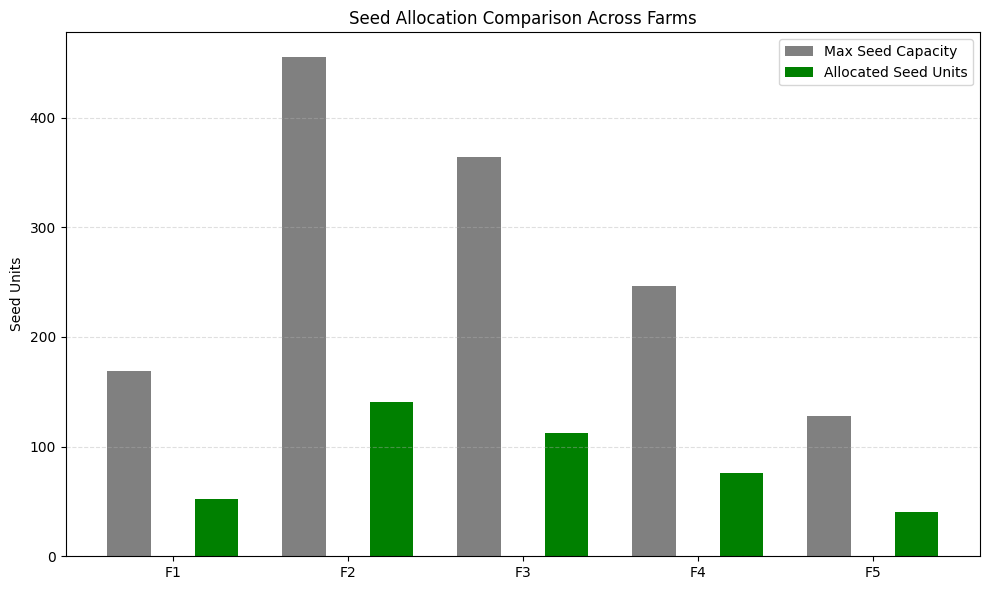

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(allocation_df))

bar_width = 0.25

# Bars
ax.bar(x - bar_width, allocation_df["Max_Seed_Capacity"], width=bar_width, label="Max Seed Capacity", color='gray')
ax.bar(x + bar_width, allocation_df["Allocated_Seed_Units"], width=bar_width, label="Allocated Seed Units", color='green')

# Labels and legend
ax.set_xticks(x)
ax.set_xticklabels(allocation_df["Farm_ID"])
ax.set_ylabel("Seed Units")
ax.set_title("Seed Allocation Comparison Across Farms")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
# === Step 7: Waste Averted Calculations ===
allocation_df["Waste_Averted_Seed_Units"] = allocation_df["Max_Seed_Capacity"] - allocation_df["Allocated_Seed_Units"]
allocation_df["Waste_Averted_kg"] = allocation_df["Waste_Averted_Seed_Units"] * seed_output_per_unit_kg

# Print table of waste averted
print("\nWaste Averted per Farm:")
print(allocation_df[["Farm_ID", "Waste_Averted_Seed_Units", "Waste_Averted_kg"]])

# Print total waste averted
total_waste_averted = allocation_df["Waste_Averted_kg"].sum()
print(f"\nTotal Waste Averted: {total_waste_averted:.2f} kg")



Waste Averted per Farm:
  Farm_ID  Waste_Averted_Seed_Units  Waste_Averted_kg
0      F1                       117              2925
1      F2                       314              7850
2      F3                       252              6300
3      F4                       170              4250
4      F5                        88              2200

Total Waste Averted: 23525.00 kg


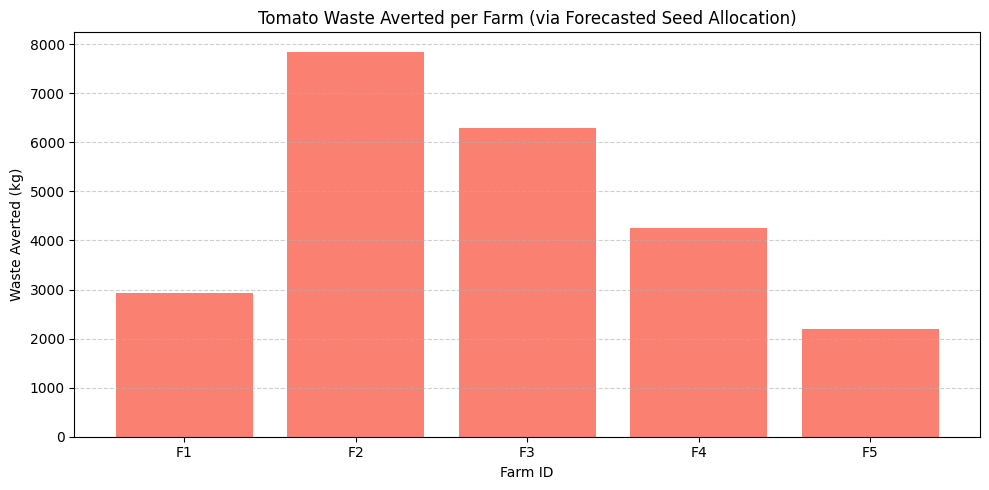

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(allocation_df["Farm_ID"], allocation_df["Waste_Averted_kg"], color="salmon")
plt.xlabel("Farm ID")
plt.ylabel("Waste Averted (kg)")
plt.title("Tomato Waste Averted per Farm (via Forecasted Seed Allocation)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Comparison with other models

ARIMA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def arima_forecast(df_coop, df_coop_test, forecast_horizon=6, order=(1,1,1), seasonal_order=(0,0,0,0)):
    """
    Forecast demand using ARIMA and evaluate performance.
    """

    # Ensure datetime and sorting
    df = df_coop.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values('Date', inplace=True)
    df.set_index('Date', inplace=True)

    y_train = df['Demand_kg']
    y_test = df_coop_test['Demand_kg'].values[:forecast_horizon]

    # Fit SARIMA
    model = SARIMAX(y_train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
    results = model.fit(disp=False)

    # Forecast
    forecast = results.get_forecast(steps=forecast_horizon)
    forecast_mean = forecast.predicted_mean
    conf_int = forecast.conf_int(alpha=0.05)

    # Evaluation
    mae = mean_absolute_error(y_test, forecast_mean)
    rmse = np.sqrt(mean_squared_error(y_test, forecast_mean))
    mape = mean_absolute_percentage_error(y_test, forecast_mean) * 100

    print("ARIMA Evaluation Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # Plot
    months = np.arange(1, forecast_horizon + 1)
    plt.figure(figsize=(10, 5))
    plt.plot(months, y_test, 'o-', label='Actual Demand', color='black')
    plt.plot(months, forecast_mean, 'o--', label='ARIMA Forecast', color='blue')
    plt.fill_between(months, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='blue', alpha=0.2, label='95% CI')
    plt.xlabel("Forecast Month")
    plt.ylabel("Demand (kg)")
    plt.title("ARIMA Forecast vs Actual Demand")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return forecast_mean.values, y_test


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA Evaluation Metrics:
MAE: 171.30
RMSE: 208.61
MAPE: 7.88%


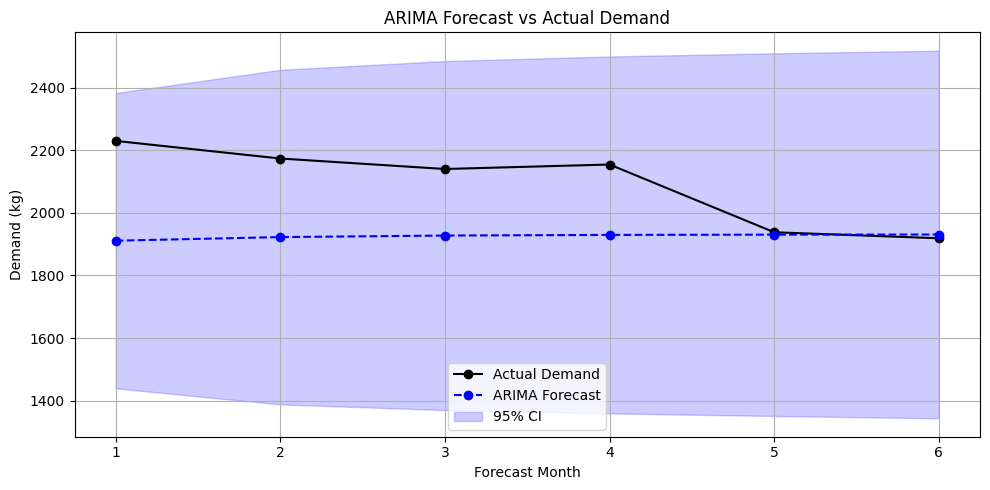

In [ ]:
# Use same train/test split as Bayesian model
forecast_arima, actual_arima = arima_forecast(df_coop, df_coop_test, forecast_horizon=6, order=(1,1,1))


Ordinary Linear Regression

Linear Regression Evaluation:
MAE: 158.58
RMSE: 193.64
MAPE: 7.58%


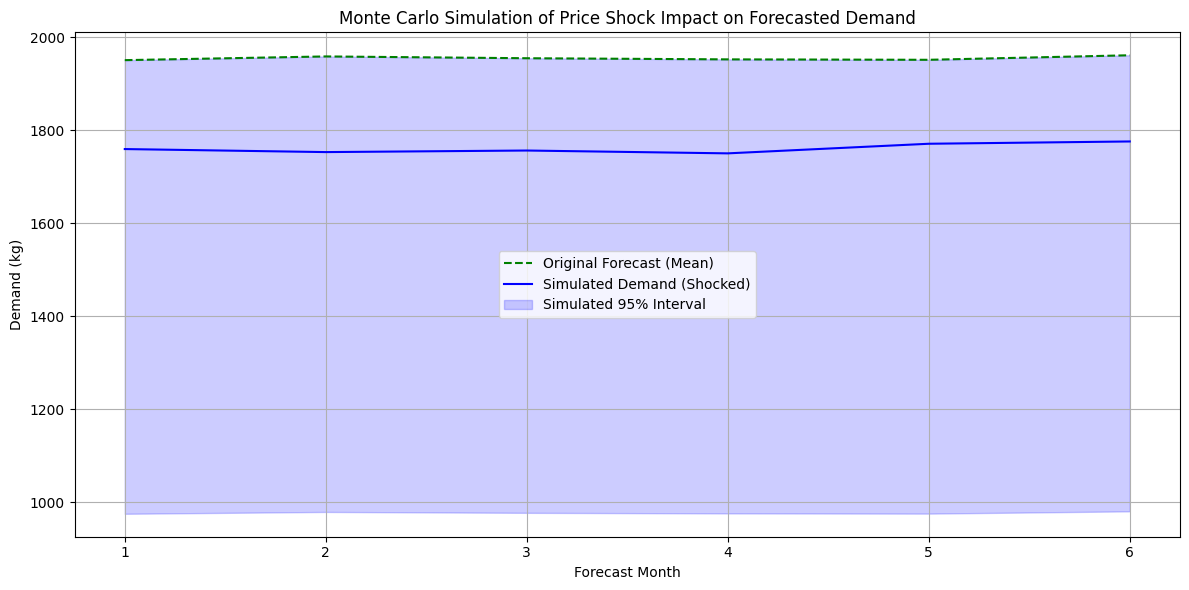

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd

# Prepare training and test features
X_train = df_coop[['AvgTemp_C', 'Rainfall_mm', 'Price_per_kg', 'Household_Income']].values
y_train = df_coop['Demand_kg'].values
X_test = df_coop_test[['AvgTemp_C', 'Rainfall_mm', 'Price_per_kg', 'Household_Income']].values
y_test = df_coop_test['Demand_kg'].values

# Fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("Linear Regression Evaluation:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

simulated_mean = np.mean(simulated_demand, axis=0)
simulated_lower = np.percentile(simulated_demand, 2.5, axis=0)
simulated_upper = np.percentile(simulated_demand, 97.5, axis=0)

# Step 2: Original forecast mean (before Monte Carlo)
original_mean = np.mean(forecasted_samples_all, axis=1)

# Step 3: Plot
months = np.arange(1, len(original_mean) + 1)

plt.figure(figsize=(12, 6))
plt.plot(months, original_mean, label="Original Forecast (Mean)", linestyle='--', color='green')
plt.plot(months, simulated_mean, label="Simulated Demand (Shocked)", color='blue')
plt.fill_between(months, simulated_lower, simulated_upper, color='blue', alpha=0.2, label="Simulated 95% Interval")
plt.xlabel("Forecast Month")
plt.ylabel("Demand (kg)")
plt.title("Monte Carlo Simulation of Price Shock Impact on Forecasted Demand")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Prophet

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpp4xdzobp/fzguwncs.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpp4xdzobp/1zxo5lwa.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=85210', 'data', 'file=/tmp/tmpp4xdzobp/fzguwncs.json', 'init=/tmp/tmpp4xdzobp/1zxo5lwa.json', 'output', 'file=/tmp/tmpp4xdzobp/prophet_modelnovddfoz/prophet_model-20250715110246.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:02:46 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:02:46 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.11/dist-packages/

Prophet Evaluation Metrics:
MAE: 144.12
RMSE: 182.20
MAPE: 6.72%


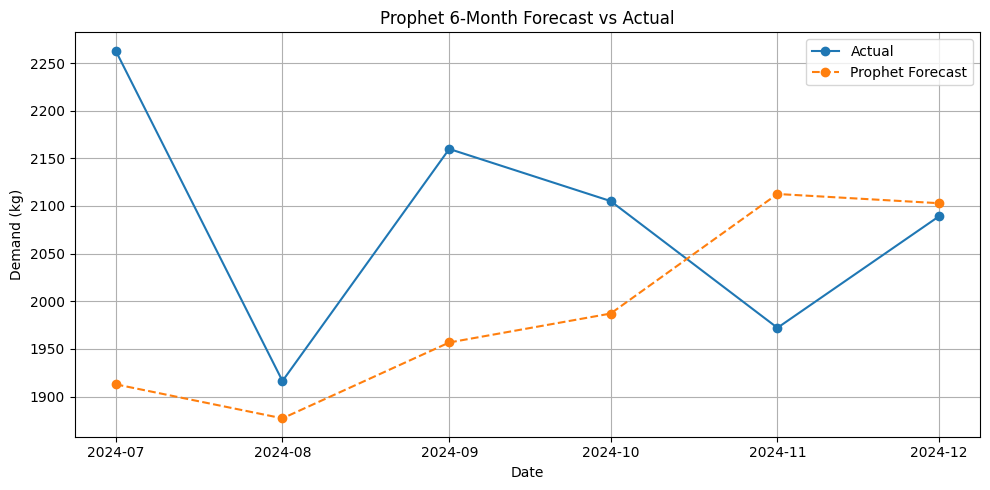

In [ ]:
from prophet import Prophet
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

# --- Prepare data (train/test split must match your previous setup) ---
df = pd.concat([df_coop, df_coop_test], ignore_index=True)
df_prophet = df[['Date', 'Demand_kg']].rename(columns={'Date': 'ds', 'Demand_kg': 'y'})

# Split
train = df_prophet.iloc[:-6]
test = df_prophet.iloc[-6:]

# --- Train Prophet model ---
model = Prophet(yearly_seasonality=True)
model.fit(train)

# --- Forecast 6 steps ahead ---
future = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future)

# --- Extract forecast ---
forecasted = forecast[['ds', 'yhat']].iloc[-6:]['yhat'].values
actual = test['y'].values

# --- Evaluation ---
mae = mean_absolute_error(actual, forecasted)
rmse = mean_squared_error(actual, forecasted) ** 0.5
mape = mean_absolute_percentage_error(actual, forecasted) * 100

print("Prophet Evaluation Metrics:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(test['ds'], actual, 'o-', label='Actual')
plt.plot(test['ds'], forecasted, 'o--', label='Prophet Forecast')
plt.title('Prophet 6-Month Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Demand (kg)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
